<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_1/REJECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [13]:
# Definimos una función que genera num_samples muestras
# siguiendo el algoritmo de muestreo por rechazo expuesto en teoria

def rejection(target_pdf, envelope_pdf, num_samples, k):
  samples = []
  accepted_samples = []
  rejected_samples = []

  for i in range(num_samples):
      x_proposal = norm.rvs(loc=0.5, scale=3)

      u = k * envelope_pdf(x_proposal) * rng.random()

      if u < target_pdf(x_proposal):
          accepted_samples.append(x_proposal)
      else:
          rejected_samples.append(x_proposal)

  accepted_samples = np.array(accepted_samples)
  rejected_samples = np.array(rejected_samples)

  return accepted_samples, rejected_samples


In [14]:
# Definimos una distribución objetivo bimodal
def target_pdf(x):
  # Para ello mezclamos dos distribuciones normales
    return 0.4 * norm.pdf(x, loc=-2, scale=1) + 0.6 * norm.pdf(x, loc=3, scale=1)

# Definimos una distribución de propuesta normal
def envelope_pdf(x):
    return norm.pdf(x, loc=0.5, scale=3)

In [15]:
# Determinamos la constante k

# Ajustamos el rango de x para evaluar las funciones objetivo y propuesta
x_range = np.linspace(-7, 7, 1000)

# Calculamos la relación objetivo/envolvente
ratio = target_pdf(x_range) / envelope_pdf(x_range)
k = np.max(ratio) # k debe ser mayor o igual al máximo de esta relación


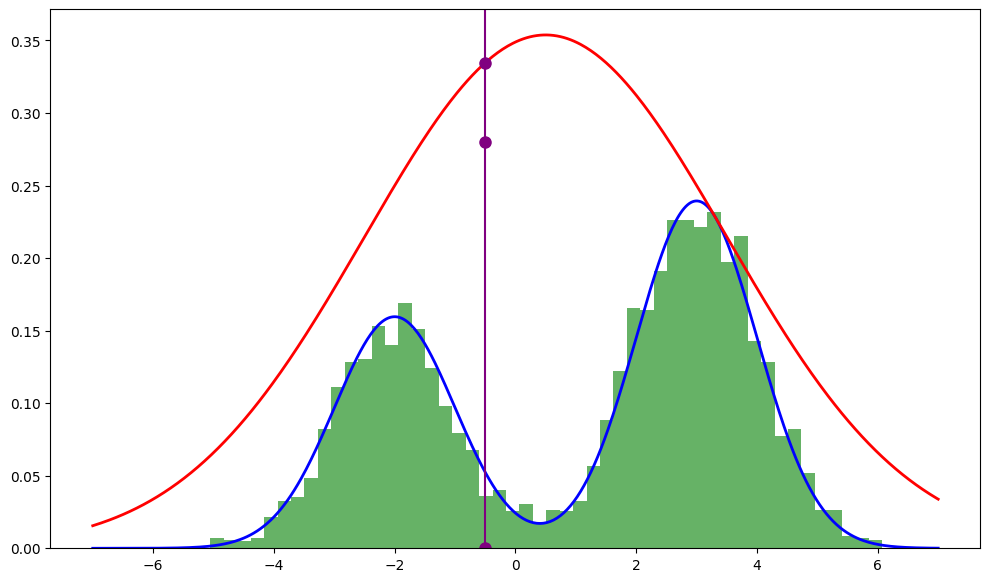

In [16]:
# Establecemos una semilla para la replicabilidad de la imagen
rng = np.random.default_rng(1)

# Generamos las muestras a partir de nuestra función
accepted_samples, rejected_samples = rejection(target_pdf, envelope_pdf, 10000, k)

# Visualizamos los resultados
plt.figure(figsize=(12, 7))
x_plot = np.linspace(-7, 7, 500)

# Graficamos la distribución objetivo
plt.plot(x_plot, target_pdf(x_plot), label='Distribución Objetivo Bimodal', color='blue', linewidth=2)

# Graficamos la envolvente escalada (k * envolvente_pdf)
plt.plot(x_plot, k * envelope_pdf(x_plot), color='red', linewidth=2)

# Generamos un histograma de las muestras aceptadas
plt.hist(accepted_samples, bins=50, density=True, alpha=0.6, color='green')

x0 = -0.5
y_at_x0 = k * envelope_pdf(x0)
y0 = 0.28

plt.axvline(x=x0, color='purple', linewidth=1.5, label=f'Línea en x_0 = {x0}')

plt.plot(x0, y_at_x0, 'o', color='purple', markersize=8)
plt.plot(x0, y0, 'o', color='purple', markersize=8)
plt.plot(x0, 0, 'o', color='purple', markersize=8)

plt.ylim(bottom=0)

# Guardamos la imagen
plt.savefig("RECHAZO.pdf")

plt.show()

In [17]:
from google.colab import files
files.download("RECHAZO.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>